The steps we should go for PCA:
* Standardize the data.
Obtain the Eigenvectors and Eigenvalues from the covariance matrix or correlation matrix, or perform Singular Value Decomposition.
* Sort eigenvalues in descending order and choose the k eigenvectors that correspond to the k largest eigenvalues where k is the number of dimensions of the new feature subspace (k ≤ d).
* Construct the projection matrix W from the selected k eigenvectors.
* Transform the original dataset X via W to obtain a k-dimensional feature subspace Y.


In [ ]:
import pandas as pd
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data" , header = None, sep = ",")
df.columns=["sepal_len", "sepal_wid" , "petal_len" , "petal_wid" , "class"]
#Drop empty lines
df.dropna(how = "all", inplace = True)
df.head()

,sepal_len,sepal_wid,petal_len,petal_wid,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
#Split the data
#4 columns are considered as X and one last column as y.
X = df.loc[: , "sepal_len" : "petal_wid"]
y = df.loc[: , "class"]

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
X_std = StandardScaler().fit_transform(X)

#EigenVectors and EigenValues
MeanVecotr = np.mean(X_std, axis=0)
CovarianceMatrix = (X_std - MeanVecotr).T.dot((X_std - MeanVecotr)) / (X_std.shape[0]-1)
print("Covariance matrix: \n" ,  CovarianceMatrix)
print("")
print("Eigendecomposition on the covariance matrix: ")
CovarianceMatrix = np.cov(X_std.T)
EigenValues , EigenVectors = np.linalg.eig(CovarianceMatrix)
print("_The Eigen values: \n" , EigenValues)
print("_The Eigen vectors: \n" , EigenVectors)

Covariance matrix: 
 [[ 1.00671141 -0.11010327  0.87760486  0.82344326]
 [-0.11010327  1.00671141 -0.42333835 -0.358937  ]
 [ 0.87760486 -0.42333835  1.00671141  0.96921855]
 [ 0.82344326 -0.358937    0.96921855  1.00671141]]

Eigendecomposition on the covariance matrix: 
_The Eigen values: 
 [2.93035378 0.92740362 0.14834223 0.02074601]
_The Eigen vectors: 
 [[ 0.52237162 -0.37231836 -0.72101681  0.26199559]
 [-0.26335492 -0.92555649  0.24203288 -0.12413481]
 [ 0.58125401 -0.02109478  0.14089226 -0.80115427]
 [ 0.56561105 -0.06541577  0.6338014   0.52354627]]


In [ ]:
print("Eigendecomposition of the standardized data based on the correlation matrix: ")
CorrelationMatrix = np.corrcoef(X_std.T)
EigenValues , EigenVectors = np.linalg.eig(CorrelationMatrix)
print("_The Eigen values: \n" , EigenValues)
print("_The Eigen vectors: \n" , EigenVectors)

Eigendecomposition of the standardized data based on the correlation matrix: 
_The Eigen values: 
 [2.91081808 0.92122093 0.14735328 0.02060771]
_The Eigen vectors: 
 [[ 0.52237162 -0.37231836 -0.72101681  0.26199559]
 [-0.26335492 -0.92555649  0.24203288 -0.12413481]
 [ 0.58125401 -0.02109478  0.14089226 -0.80115427]
 [ 0.56561105 -0.06541577  0.6338014   0.52354627]]


In [ ]:
print("Eigendecomposition of the raw data based on the correlation matrix: ")
RawCorellation = np.corrcoef(X.T)
EigenValues , EigenVectors = np.linalg.eig(RawCorellation)
print("_The Eigen values: \n" , EigenValues)
print("_The Eigen vectors: \n" , EigenVectors)

Eigendecomposition of the raw data based on the correlation matrix: 
_The Eigen values: 
 [2.91081808 0.92122093 0.14735328 0.02060771]
_The Eigen vectors: 
 [[ 0.52237162 -0.37231836 -0.72101681  0.26199559]
 [-0.26335492 -0.92555649  0.24203288 -0.12413481]
 [ 0.58125401 -0.02109478  0.14089226 -0.80115427]
 [ 0.56561105 -0.06541577  0.6338014   0.52354627]]


In [ ]:
#Selectign the principal components
#Sorting the eigen pairs
#Performing an SVD
u,s,v = np.linalg.svd(X_std.T)
EigenPairs = [(np.abs(EigenValues[i]), EigenVectors[:,i]) for i in range(len(EigenValues))]
EigenPairs.sort(key = lambda x: x[0], reverse=True)
print("Eigenvalues in descending order: ")
for i in EigenPairs:
    print(i[0])

Eigenvalues in descending order: 
2.9108180837520528
0.9212209307072254
0.1473532783050958
0.020607707235624842


In [ ]:
#Choosing how many principal components?
#Calculated the explained variance
Total = sum(EigenValues)
ExplainedVariance = [(i / Total)*100 for i in sorted(EigenValues , reverse = True)]
ExplainedVarianceCumulative = np.cumsum(ExplainedVariance)
print(ExplainedVarianceCumulative)

[ 72.77045209  95.80097536  99.48480732 100.        ]


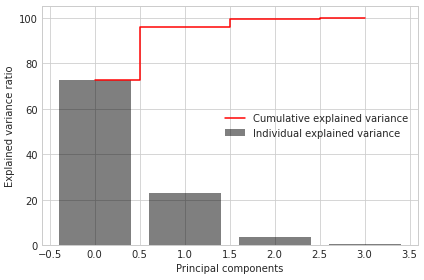

In [ ]:
from matplotlib import pyplot as plt
with plt.style.context("seaborn-whitegrid"):
    plt.figure(figsize = (6, 4))
    plt.bar(range(4), ExplainedVariance , alpha = 0.5, align = "center" , label = "Individual explained variance" , color = "k")
    plt.step(range(4), ExplainedVarianceCumulative, where = 'mid', label = "Cumulative explained variance" , color = "r")
    plt.ylabel("Explained variance ratio")
    plt.xlabel("Principal components")
    plt.legend(loc = "best")
    plt.tight_layout()

Projection matrix: 
 [[ 0.52237162 -0.37231836]
 [-0.26335492 -0.92555649]
 [ 0.58125401 -0.02109478]
 [ 0.56561105 -0.06541577]]



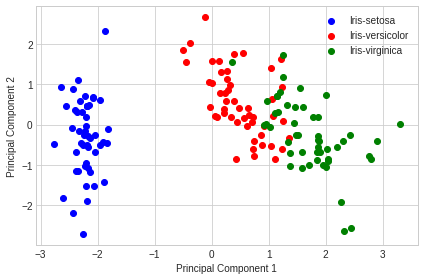

In [ ]:
#Projection matrix
ProjectionMatrix = np.hstack((EigenPairs[0][1].reshape(4,1), EigenPairs[1][1].reshape(4,1)))
print("Projection matrix: \n" , ProjectionMatrix)
#transform data into new subspace
Y = X_std.dot(ProjectionMatrix)
print("")
with plt.style.context("seaborn-whitegrid"):
    plt.figure(figsize=(6, 4))
    for lab, col in zip(("Iris-setosa" , "Iris-versicolor", "Iris-virginica"),("b", "r", "g")):
        plt.scatter(Y[y == lab, 0], Y[y == lab, 1] , label = lab , c = col)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

***PCA in scikit-learn Directly***

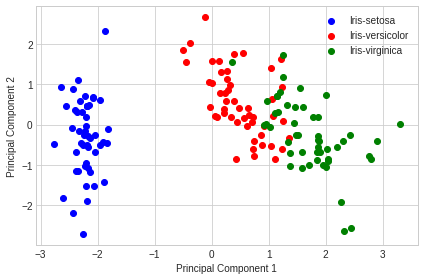

In [ ]:
from sklearn.decomposition import PCA as sklearnPCA
PCA = sklearnPCA(n_components=2)
Y = PCA.fit_transform(X_std)
with plt.style.context("seaborn-whitegrid"):
    plt.figure(figsize=(6, 4))
    for lab, col in zip(("Iris-setosa" , "Iris-versicolor", "Iris-virginica"),("b", "r", "g")):
        plt.scatter(Y[y == lab, 0], -Y[y == lab, 1] , label = lab , c = col)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()